In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the news data
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# 1. Basic Cleaning
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Date Conversion (Financial news uses UTC-4 usually)
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date'])

# 3. Simple Headline Length Stat
df['headline_len'] = df['headline'].apply(len)

print(f"Dataset Stats: {df.shape[0]} rows")
print(f"Top Publishers:\n{df['publisher'].value_counts().head(5)}")

Dataset Stats: 55987 rows
Top Publishers:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Name: count, dtype: int64


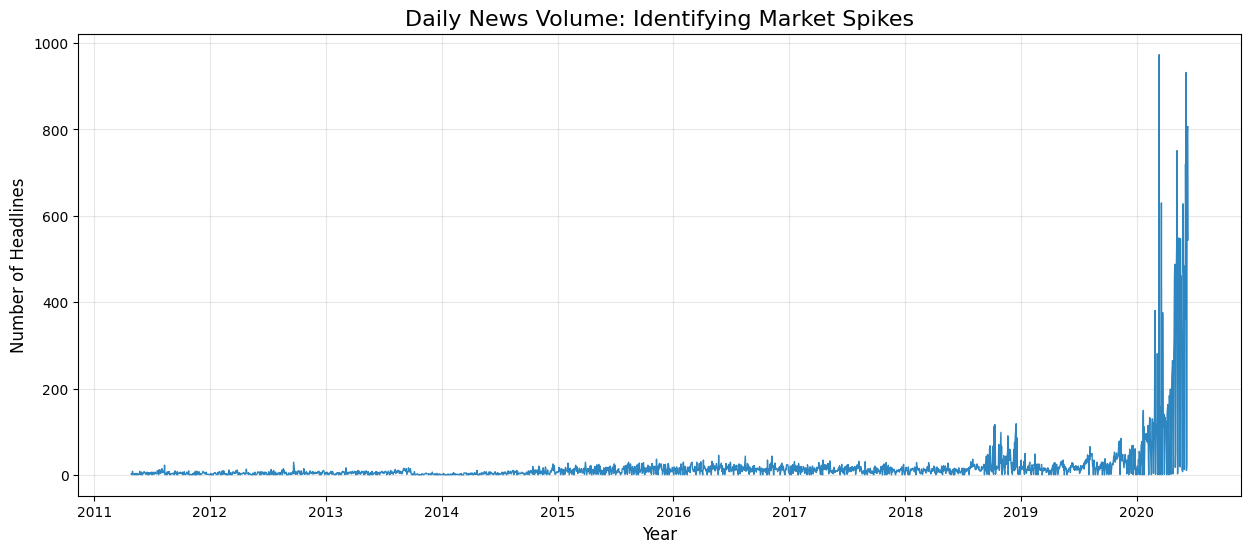

In [4]:
# Grouping by day to see the volume of news over time
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15, 6))
daily_counts.plot(kind='line', color='#2E86C1', lw=1)

plt.title('Daily News Volume: Identifying Market Spikes', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\mekli\AppData\Local\Temp\ipykernel_13492\2408069239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')


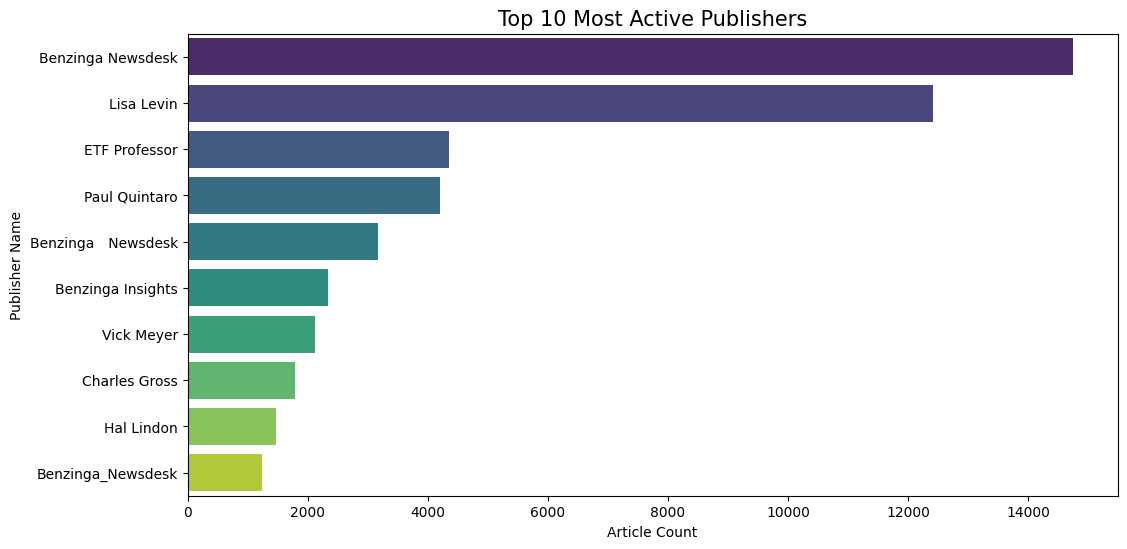

In [5]:
# Get the top 10 most active publishers
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')
plt.title('Top 10 Most Active Publishers', fontsize=15)
plt.xlabel('Article Count')
plt.ylabel('Publisher Name')
plt.show()
